<a href="https://colab.research.google.com/github/GovardhanDatta/Projects/blob/main/churn_prediction_ml_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Pipeline for Customer Churn Prediction

This project builds a **production-style machine learning pipeline** to predict customer churn.

The focus is not just model accuracy, but creating a **scalable and reusable workflow** using preprocessing pipelines and model integration.

Goal: Predict whether a customer will churn (1) or not (0).

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

import joblib

In [6]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.shape

(7043, 21)

In [10]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
x=df.drop('Churn',axis=1)
y=df['Churn']

In [11]:
categorical_cols=x.select_dtypes(include=['object']).columns
numerical_cols=x.select_dtypes(include=['int64','float64']).columns

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [13]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [14]:
pipeline_lr=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ('model',LogisticRegression(max_iter=1000))
])

In [15]:
pipeline_lr.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [16]:
y_pred_lr=pipeline_lr.predict(x_test)

In [17]:
print('Logistic Regression Accuracy:',accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.8261178140525195
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.60      0.64       373

    accuracy                           0.83      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.83      0.82      1409



## Logistic Regression Results

The Logistic Regression model achieved an accuracy of **82.6%**.

However, accuracy alone is not sufficient for evaluating churn prediction models.

Key observations:

• The model performs well for non-churn customers (high precision and recall)  
• The recall for churn customers is relatively low (60%)  
• This means the model fails to detect a significant portion of customers who are likely to churn  

In business scenarios, detecting churn is more important than overall accuracy. Therefore, improving recall for churn customers is a key objective.

In [18]:
pipeline_rf=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(n_estimators=200,random_state=42))
])

In [19]:
pipeline_rf.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [20]:
y_pred_rf=pipeline_rf.predict(x_test)

In [21]:
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy: 0.801277501774308
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.68      0.47      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [22]:
joblib.dump(pipeline_rf,'churn_model_pipeline.pkl')

['churn_model_pipeline.pkl']

# Data Preprocessing and Pipeline Creation

In this stage, we prepare the dataset for machine learning and build a preprocessing pipeline.

Real-world datasets often contain:

• Categorical variables  
• Numerical variables  
• Missing values  
• Different scales  

To handle this properly and avoid data leakage, we use:

• ColumnTransformer for preprocessing  
• Pipeline for combining preprocessing and model training  

This ensures a clean, reusable, and production-ready workflow.

In [23]:
categorical_cols=x.select_dtypes(include=['object']).columns
numerical_cols=x.select_dtypes(include=['int64','float64']).columns

print('Categorical Columns:',list(categorical_cols))
print('Numerical Columns:',list(numerical_cols))

Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [24]:
if 'TotalCharges' in x.columns:
    x['TotalCharges']=pd.to_numeric(x['TotalCharges'],errors='coerce')

x=x.dropna()
y=y[x.index]

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_transformer=Pipeline(steps=[
    ('scalar',StandardScaler())
])

In [26]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [27]:
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    transformers=[
        ('num',numeric_transformer,numerical_cols),
        ('cat',categorical_transformer,categorical_cols)
    ]
)

## Why Use a Pipeline?

Using a pipeline ensures:

• No data leakage  
• Consistent preprocessing  
• Clean and maintainable code  
• Easy deployment  

This approach is widely used in production machine learning systems.

In [28]:
from sklearn.linear_model import LogisticRegression

pipeline_lr=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ('model',LogisticRegression(max_iter=1000))
])

In [29]:
pipeline_lr.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scalar',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [30]:
y_pred_lr = pipeline_lr.predict(x_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8261178140525195
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.60      0.64       373

    accuracy                           0.83      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.83      0.82      1409



# Model Training and Comparison

In this stage, we train multiple machine learning models and compare their performance.

Using multiple models helps:

• Identify the best-performing algorithm  
• Understand model behavior  
• Improve prediction performance  

We will train:

• Logistic Regression (baseline model)  
• Random Forest (advanced model)  

We will also handle class imbalance to improve churn detection.

In [31]:
from sklearn.linear_model import LogisticRegression

pipeline_lr=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(max_iter=1000,class_weight='balanced'))
])

pipeline_lr.fit(x_train,y_train)
y_pred_lr=pipeline_lr.predict(x_test)

from sklearn.metrics import classification_report,accuracy_score

print('Logistic Regression Accuracy:',accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.7863733144073811
              precision    recall  f1-score   support

           0       0.90      0.79      0.85      1036
           1       0.57      0.76      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.79      1409



In [32]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(x_train,y_train)

y_pred_rf=pipeline_rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.801277501774308
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.68      0.47      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [33]:
pipeline_rf_bal=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ('model',RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf_bal.fit(x_train, y_train)

y_pred_rf_bal = pipeline_rf_bal.predict(x_test)

print("Balanced Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print(classification_report(y_test, y_pred_rf_bal))

Balanced Random Forest Accuracy: 0.8034066713981547
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



## Random Forest Results Analysis

The Random Forest model achieved an accuracy of approximately **80%**.

However, the recall for churn customers was relatively low (~47%), meaning many churn cases were not detected.

After applying class balancing:

• Recall improved from 47% → 53%  
• F1-score improved  
• The model became better at detecting churn customers  

Although overall accuracy remained similar, the balanced model provides **better business value** by identifying more customers at risk of leaving.

# Advanced Model Evaluation

In this stage, we evaluate the model using advanced metrics that are more suitable for imbalanced datasets.

Accuracy alone is not sufficient for churn prediction. Instead, we use:

• ROC Curve and ROC-AUC Score  
• Precision–Recall Curve  

These metrics help us better understand the model's ability to detect churn customers.

In [34]:
rf_probs=pipeline_rf.predict_proba(x_test)[:,1]

In [35]:
from sklearn.metrics import roc_curve,roc_auc_score

fpr,tpr,thresholds=roc_curve(y_test,rf_probs)

auc_score=roc_auc_score(y_test,rf_probs)

print('ROC AUC Score:',auc_score)

ROC AUC Score: 0.8470310122454895


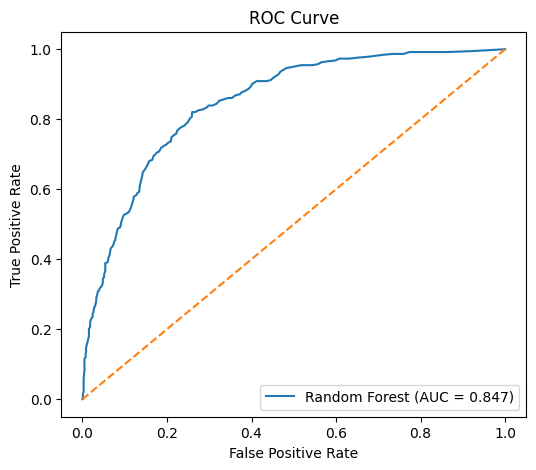

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label='Random Forest (AUC = %.3f)'%auc_score)
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## ROC Curve Insight

The ROC curve shows how well the model distinguishes between churn and non-churn customers.

An ROC-AUC score closer to 1 indicates better performance.

This metric is especially useful for evaluating classification models on imbalanced datasets.

In [37]:
from sklearn.metrics import precision_recall_curve

precision,recall,thresholds=precision_recall_curve(y_test,rf_probs)

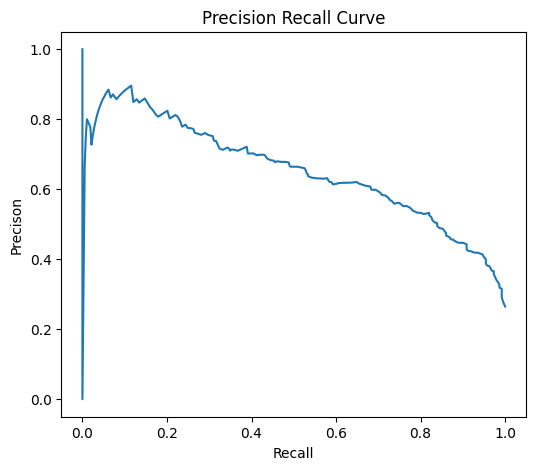

In [38]:
plt.figure(figsize=(6,5))

plt.plot(recall,precision)

plt.xlabel('Recall')
plt.ylabel('Precison')
plt.title('Precision Recall Curve')

plt.show()

## Precision–Recall Curve Insight

The Precision–Recall curve focuses on the performance of the churn class.

High recall means more churn customers are detected, while high precision means fewer false alarms.

This metric is particularly important in churn prediction, where detecting at-risk customers is critical.

In [39]:
for t in [0.3,0.4,0.5]:
    preds=(rf_probs >= t).astype(int)
    print(f'\nThreshold:{t}')
    print(classification_report(y_test,preds))


Threshold:0.3
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1036
           1       0.56      0.75      0.64       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409


Threshold:0.4
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1036
           1       0.62      0.60      0.61       373

    accuracy                           0.79      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409


Threshold:0.5
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.68      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      

## Threshold Adjustment

By changing the prediction threshold, we can control the trade-off between precision and recall.

Lower threshold → Higher recall (detect more churn)  
Higher threshold → Higher precision (fewer false positives)  

This allows businesses to adjust the model based on their priorities.